# Questão 1
Por que a função de ativação logística foi um ingrediente chave no treinamento das primeiras redes MLPs?

In [ ]:

# A função logística (sigmoide) foi crucial porque introduz não linearidade na rede,
# permitindo que ela resolva problemas não linearmente separáveis.
# Além disso, sua derivada é simples, o que facilita o cálculo do gradiente durante a retropropagação.


# Questão 2
Três funções de ativação diferentes das vistas em aula, com seus gráficos e derivadas.

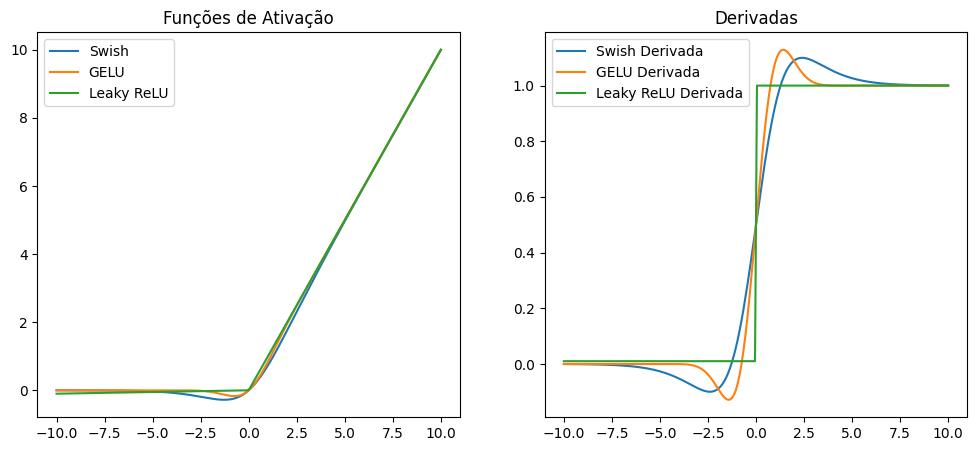

In [1]:

import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-10, 10, 200)

# Swish
swish = x * (1 / (1 + np.exp(-x)))
swish_derivative = (1 / (1 + np.exp(-x))) + swish * (1 - (1 / (1 + np.exp(-x))))

# GELU (aproximação)
gelu = 0.5 * x * (1 + np.tanh(np.sqrt(2/np.pi)*(x + 0.044715 * x**3)))
gelu_derivative = 0.5 * (1 + np.tanh(0.797885 * (x + 0.044715 * x**3))) +                   0.5 * x * (1 - np.tanh(0.797885 * (x + 0.044715 * x**3))**2) *                   0.797885 * (1 + 3 * 0.044715 * x**2)

# Leaky ReLU
leaky_relu = np.where(x > 0, x, 0.01 * x)
leaky_relu_derivative = np.where(x > 0, 1, 0.01)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.title('Funções de Ativação')
plt.plot(x, swish, label='Swish')
plt.plot(x, gelu, label='GELU')
plt.plot(x, leaky_relu, label='Leaky ReLU')
plt.legend()

plt.subplot(1, 2, 2)
plt.title('Derivadas')
plt.plot(x, swish_derivative, label='Swish Derivada')
plt.plot(x, gelu_derivative, label='GELU Derivada')
plt.plot(x, leaky_relu_derivative, label='Leaky ReLU Derivada')
plt.legend()

plt.show()


# Questão 3
Desenho da rede MLP para resolver o problema XOR.

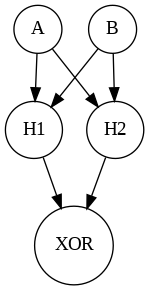

In [11]:
from graphviz import Digraph
from IPython.display import Image

# Criação do grafo
dot = Digraph(format='png')
dot.attr('node', shape='circle')

# Entradas
dot.node('A', 'A')
dot.node('B', 'B')

# Ocultas
dot.node('H1', 'H1')
dot.node('H2', 'H2')

# Saída
dot.node('Y', 'XOR')

# Conexões corretas
dot.edges([('A', 'H1'), ('A', 'H2'), ('B', 'H1'), ('B', 'H2')])
dot.edge('H1', 'Y')
dot.edge('H2', 'Y')

# Gerar e salvar a imagem
file_path = '/mnt/data/XOR_MLP'
dot.render(file_path, cleanup=True)

# Exibir a imagem no notebook
Image(filename=file_path + '.png')


# Questão 4
Cálculo das dimensões dos pesos, bias e saída.

In [ ]:

# a) X tem dimensão (N, 10) onde N é o número de amostras.

# b) Wh tem dimensão (10, 50) pois conecta 10 entradas a 50 neurônios ocultos.
#    bh tem dimensão (50,) - um bias para cada neurônio da camada oculta.

# c) Wo tem dimensão (50, 3) pois conecta 50 neurônios ocultos a 3 neurônios de saída.
#    bo tem dimensão (3,) - um bias para cada neurônio da saída.

# d) A saída Y terá dimensão (N, 3).

# e) Equação da rede:
# Y = ReLU(X @ Wh + bh) @ Wo + bo


# Questão 5
Quantidade de neurônios na saída e funções de ativação.

In [ ]:

# Para classificar SPAM vs HAM (classificação binária):
# - 1 neurônio na saída
# - Função de ativação: sigmoid

# Para classificar MNIST (10 classes - dígitos de 0 a 9):
# - 10 neurônios na saída
# - Função de ativação: softmax


# Questão 6
Hiperparâmetros da rede e como evitar overfitting.

In [ ]:

# Hiperparâmetros incluem:
# - Taxa de aprendizado
# - Número de neurônios nas camadas ocultas
# - Número de camadas ocultas
# - Número de épocas
# - Tamanho do batch
# - Função de ativação
# - Otimizador
# - Técnicas de regularização (Dropout, L2, Early Stopping)

# Para evitar overfitting:
# - Usar Dropout
# - Reduzir complexidade (menos neurônios ou camadas)
# - Usar regularização L2
# - Early Stopping
# - Aumentar o conjunto de dados (Data Augmentation)


# Questão 7
Reimplementação utilizando tf.keras.layers.Dense

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9483 - loss: 0.1337  
Acurácia no teste: 0.9350


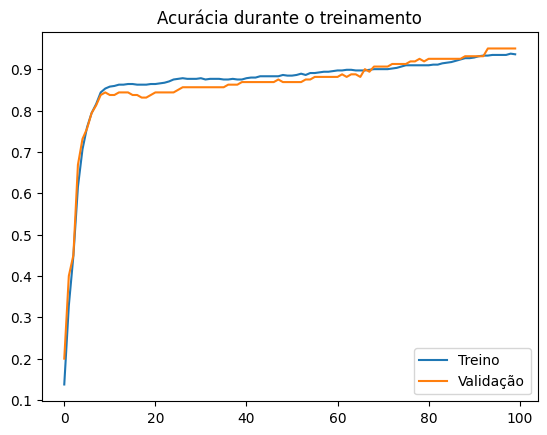

In [3]:

import tensorflow as tf
from tensorflow import keras
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Gerando dados simples
X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Criando o modelo com Dense
model = keras.models.Sequential([
    keras.layers.Dense(10, activation='relu', input_shape=(2,)),
    keras.layers.Dense(5, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
history = model.fit(X_train, y_train, epochs=100, validation_split=0.2, verbose=0)

# Avaliação
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Acurácia no teste: {test_acc:.4f}")

plt.plot(history.history['accuracy'], label='Treino')
plt.plot(history.history['val_accuracy'], label='Validação')
plt.title('Acurácia durante o treinamento')
plt.legend()
plt.show()


# Questão 8
Implementação do Early Stopping manual.

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Early stopping na época 460


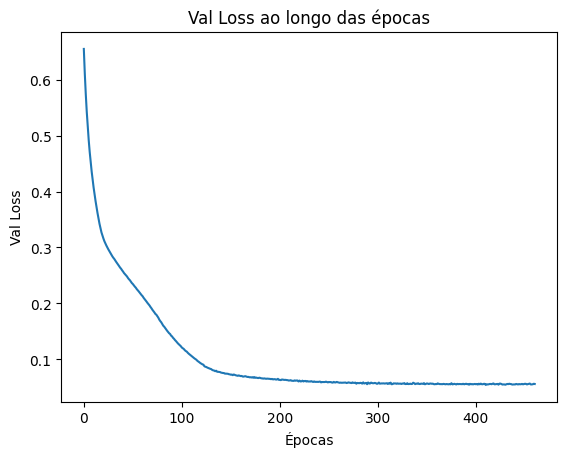

In [12]:
import os
import matplotlib.pyplot as plt

best_loss = float('inf')
patience = 50
wait = 0

model = keras.models.Sequential([
    keras.layers.Dense(10, activation='relu', input_shape=(2,)),
    keras.layers.Dense(5, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

history_list = []

# Cria a pasta (opcional)
os.makedirs('model_checkpoints', exist_ok=True)

for epoch in range(1000):
    history = model.fit(X_train, y_train, epochs=1, validation_split=0.2, verbose=0)
    val_loss = history.history['val_loss'][0]
    history_list.append(val_loss)

    if val_loss < best_loss:
        best_loss = val_loss
        model.save_weights('model_checkpoints/best_model.weights.h5')
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            print(f"Early stopping na época {epoch}")
            break

plt.plot(history_list)
plt.title("Val Loss ao longo das épocas")
plt.xlabel('Épocas')
plt.ylabel('Val Loss')
plt.show()


# Questão 9
Utilizando MomentumOptimizer no TensorFlow

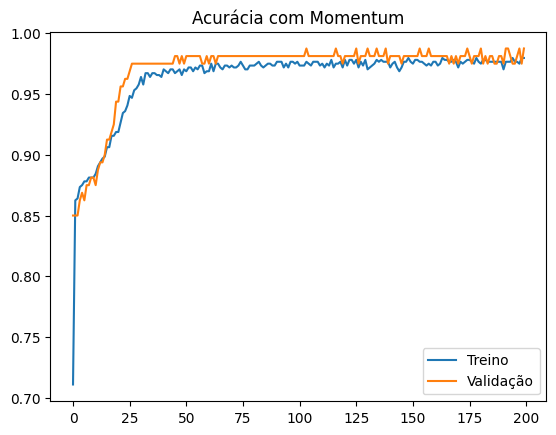

In [5]:

# Exemplo atualizado com keras.optimizers.SGD com momentum
model = keras.models.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(2,)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

optimizer = keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)
model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=200, validation_split=0.2, verbose=0)
plt.plot(history.history['accuracy'], label='Treino')
plt.plot(history.history['val_accuracy'], label='Validação')
plt.legend()
plt.title('Acurácia com Momentum')
plt.show()


# Questão 10
Classificação de 3 classes com TensorFlow

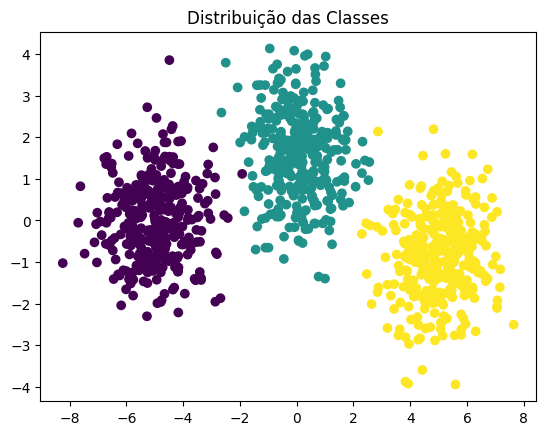

In [6]:

from sklearn.datasets import make_blobs

# Gerar os dados
N = 1000
centers = [[-5, 0], [0, 1.5], [5, -1]]
X_, y_ = make_blobs(n_samples=N, centers=centers, random_state=42)

plt.scatter(X_[:, 0], X_[:, 1], c=y_, cmap='viridis')
plt.title('Distribuição das Classes')
plt.show()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


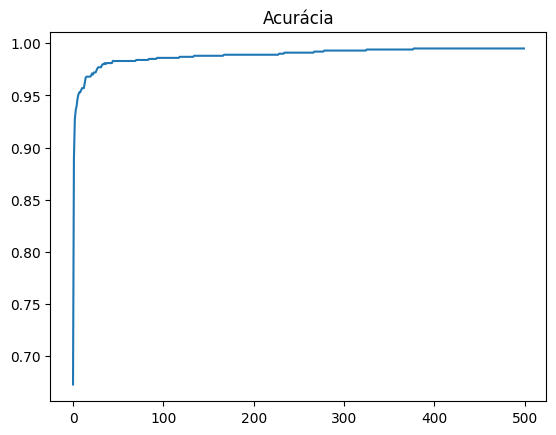

In [7]:

# Criar o modelo
model = keras.models.Sequential([
    keras.layers.Dense(3, input_shape=(2,), activation='softmax')
])

model.compile(loss='sparse_categorical_crossentropy', optimizer='sgd', metrics=['accuracy'])

# Treinar
history = model.fit(X_, y_, epochs=500, verbose=0)

plt.plot(history.history['accuracy'])
plt.title('Acurácia')
plt.show()


565/565 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


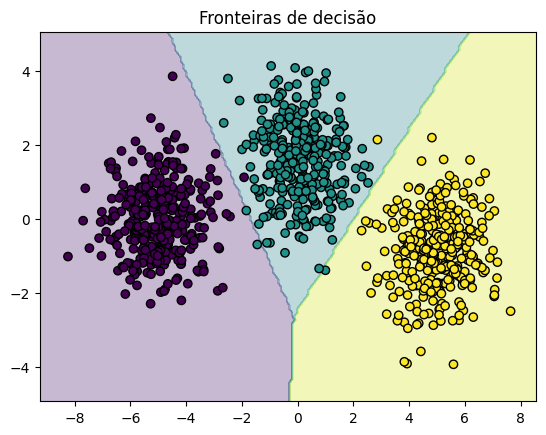

In [8]:

# Plotando fronteiras de decisão
import numpy as np

x_min, x_max = X_[:, 0].min() - 1, X_[:, 0].max() + 1
y_min, y_max = X_[:, 1].min() - 1, X_[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))
grid = np.c_[xx.ravel(), yy.ravel()]
preds = model.predict(grid)
Z = np.argmax(preds, axis=1)
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
plt.scatter(X_[:, 0], X_[:, 1], c=y_, cmap='viridis', edgecolor='k')
plt.title('Fronteiras de decisão')
plt.show()
